In [ ]:
import pandas as pd
import numpy as np

# Task 1: Load and explore
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
columns = ['variance', 'skewness', 'curtosis', 'entropy', 'class']

df = pd.read_csv(url, header=None, names=columns)

# 1. Display first five samples
print(df.head())

# 2. Determine dataset dimensions
print(df.shape)

# 3. Identify missing values
print(df.isna().sum())

# 4. Descriptive statistics
print(df.describe())

   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0
(1372, 5)
variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64
          variance     skewness     curtosis      entropy        class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     1.000000
max       6.824800    12.951600    17.927400     2.

In [ ]:
df["class"].value_counts()

,count
class,
0,762
1,610


Task 2

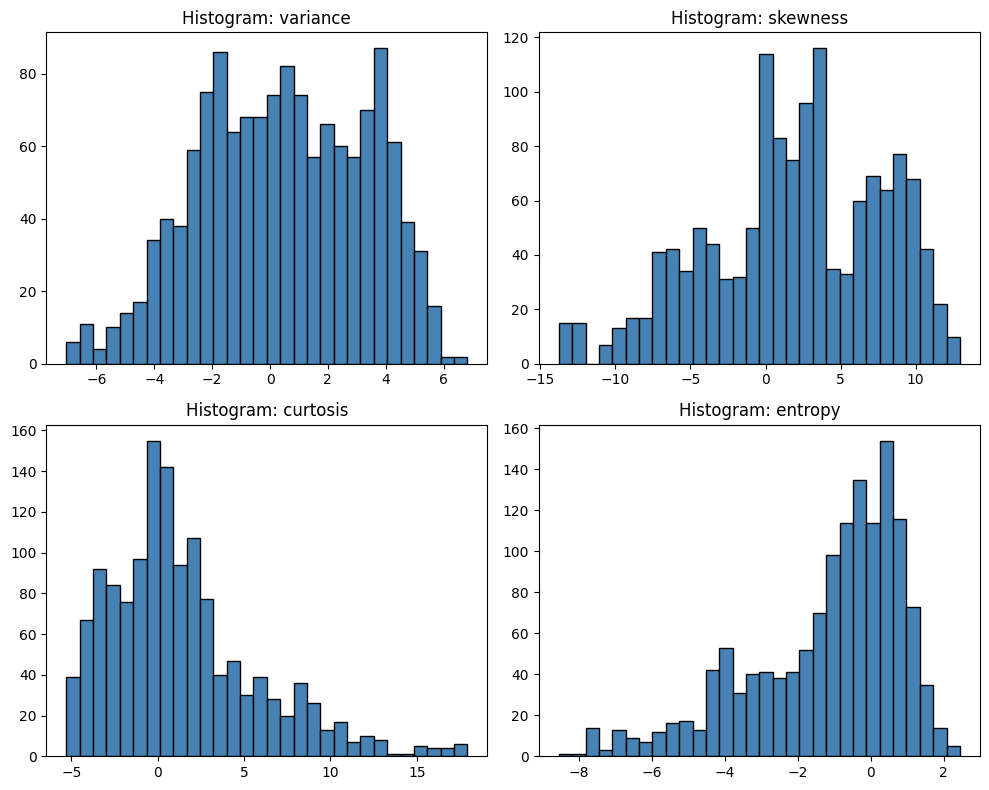

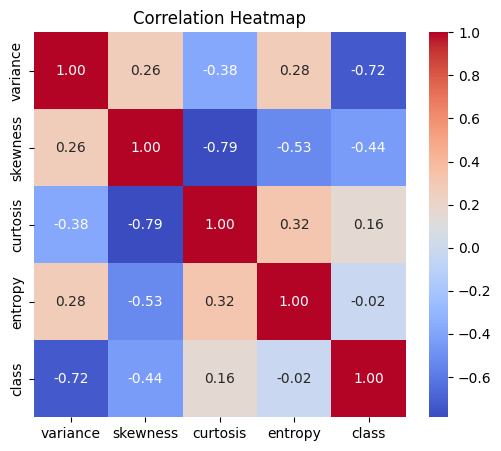

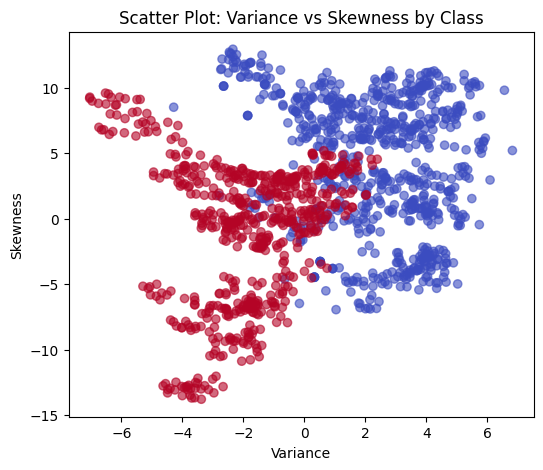

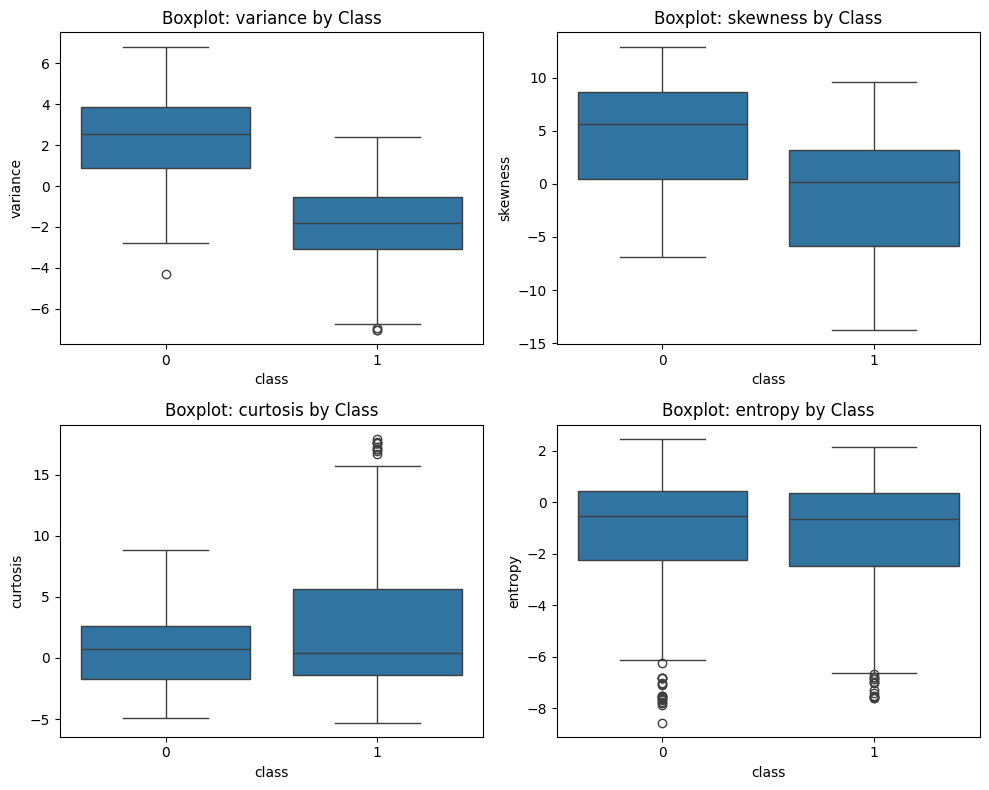

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Histograms (subplot grid) ---
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for i, col in enumerate(['variance', 'skewness', 'curtosis', 'entropy']):
    ax = axes[i//2, i%2]
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='black')
    ax.set_title(f'Histogram: {col}')
plt.tight_layout()
plt.show()

# --- Correlation Heatmap ---
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# --- Scatter Plot (pick 2 features, color by class) ---
plt.figure(figsize=(6, 5))
plt.scatter(df['variance'], df['skewness'], c=df['class'], cmap='coolwarm', alpha=0.6)
plt.xlabel('Variance')
plt.ylabel('Skewness')
plt.title('Scatter Plot: Variance vs Skewness by Class')
plt.show()

# --- Boxplots (subplot grid, split by class) ---
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for i, col in enumerate(['variance', 'skewness', 'curtosis', 'entropy']):
    ax = axes[i//2, i%2]
    sns.boxplot(x='class', y=col, data=df, ax=ax)
    ax.set_title(f'Boxplot: {col} by Class')
plt.tight_layout()
plt.show()

Task 3

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[['variance', 'skewness', 'curtosis', 'entropy']]
y = df['class']

# Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit scaler on TRAIN only, then transform both
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)   # note: transform, NOT fit_transform

print(X_train.shape, X_test.shape)

(1097, 4) (275, 4)


Task 4

In [ ]:
class Perceptron:
    def __init__(self, n_features, learning_rate=0.01, epochs=50):
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.lr = learning_rate
        self.epochs = epochs
        self.errors_per_epoch = []
        self.weight_history = []
        self.bias_history = []

    def step_function(self, z):
        if z>=0:
          return 1
        else :
          return 0

    def predict(self, x):
        z = np.dot(self.weights, x) + self.bias
        return self.step_function(z)

    def fit(self, X, y):
        for epoch in range(self.epochs):
            errors = 0
            for xi, yi in zip(X, y):
                y_pred = self.predict(xi)
                update = self.lr * (yi - y_pred)
                self.weights += update * xi
                self.bias += update
                errors += int(update != 0.0)
            self.errors_per_epoch.append(errors)
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)
            print(f"Epoch {epoch+1}: Misclassified={errors}, Weights={self.weights}, Bias={self.bias:.4f}")

Task 5

In [ ]:
n_features = X_train.shape[1]
model1 = Perceptron(n_features=n_features, learning_rate=0.01, epochs=50)
model1.fit(X_train, y_train)

Epoch 1: Misclassified=51, Weights=[-0.06024909 -0.08407687 -0.06300015  0.00226864], Bias=-0.0300
Epoch 2: Misclassified=32, Weights=[-0.08625065 -0.10215292 -0.07663789  0.0073922 ], Bias=-0.0300
Epoch 3: Misclassified=27, Weights=[-0.09932445 -0.11330756 -0.08197553  0.00545098], Bias=-0.0400
Epoch 4: Misclassified=25, Weights=[-0.07988243 -0.11840653 -0.10632953 -0.00732292], Bias=-0.0500
Epoch 5: Misclassified=27, Weights=[-0.10986763 -0.1248832  -0.1030505  -0.00681503], Bias=-0.0400
Epoch 6: Misclassified=20, Weights=[-0.10451397 -0.12636185 -0.11458703  0.01092347], Bias=-0.0600
Epoch 7: Misclassified=20, Weights=[-0.10701729 -0.14692623 -0.10333013  0.00774974], Bias=-0.0600
Epoch 8: Misclassified=23, Weights=[-0.11516546 -0.14813196 -0.11435912 -0.00815023], Bias=-0.0500
Epoch 9: Misclassified=21, Weights=[-0.11519398 -0.13957003 -0.13408384 -0.00165482], Bias=-0.0600
Epoch 10: Misclassified=22, Weights=[-0.13032592 -0.15848746 -0.12326961 -0.00658708], Bias=-0.0600
Epoch 11:

Accuracy:  0.9818
Precision: 0.9606
Recall:    1.0000
F1-score:  0.9799
Confusion Matrix:
 [[148   5]
 [  0 122]]


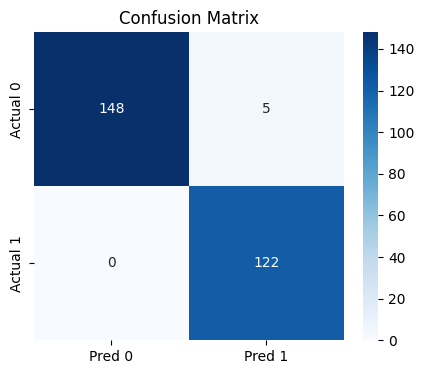

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions on test set
y_pred_test = [model1.predict(xi) for xi in X_test]

acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test)
rec = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)
cm = confusion_matrix(y_test, y_pred_test)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print("Confusion Matrix:\n", cm)

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred 0','Pred 1'], yticklabels=['Actual 0','Actual 1'])
plt.title('Confusion Matrix')
plt.show()

Task 7

Epoch 1: Misclassified=51, Weights=[-0.00602491 -0.00840769 -0.00630001  0.00022686], Bias=-0.0030
Epoch 2: Misclassified=32, Weights=[-0.00862507 -0.01021529 -0.00766379  0.00073922], Bias=-0.0030
Epoch 3: Misclassified=27, Weights=[-0.00993244 -0.01133076 -0.00819755  0.0005451 ], Bias=-0.0040
Epoch 4: Misclassified=25, Weights=[-0.00798824 -0.01184065 -0.01063295 -0.00073229], Bias=-0.0050
Epoch 5: Misclassified=27, Weights=[-0.01098676 -0.01248832 -0.01030505 -0.0006815 ], Bias=-0.0040
Epoch 6: Misclassified=20, Weights=[-0.0104514  -0.01263618 -0.0114587   0.00109235], Bias=-0.0060
Epoch 7: Misclassified=20, Weights=[-0.01070173 -0.01469262 -0.01033301  0.00077497], Bias=-0.0060
Epoch 8: Misclassified=23, Weights=[-0.01151655 -0.0148132  -0.01143591 -0.00081502], Bias=-0.0050
Epoch 9: Misclassified=21, Weights=[-0.0115194  -0.013957   -0.01340838 -0.00016548], Bias=-0.0060
Epoch 10: Misclassified=22, Weights=[-0.01303259 -0.01584875 -0.01232696 -0.00065871], Bias=-0.0060
Epoch 11:

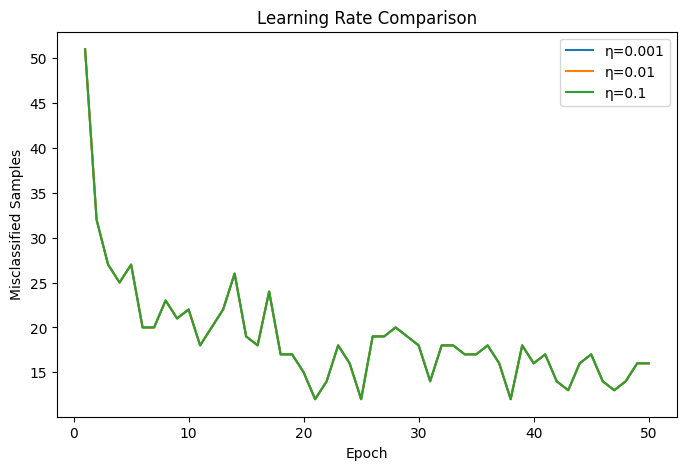

In [ ]:
learning_rates = [0.001, 0.01, 0.1]
histories = {}

for lr in learning_rates:
    model_lr = Perceptron(n_features=X_train.shape[1], learning_rate=lr, epochs=50)
    model_lr.fit(X_train, y_train)
    histories[lr] = model_lr.errors_per_epoch
    print("---")

# Plot comparison
plt.figure(figsize=(8,5))
for lr, errors in histories.items():
    plt.plot(range(1, 51), errors, label=f'η={lr}')
plt.xlabel('Epoch')
plt.ylabel('Misclassified Samples')
plt.title('Learning Rate Comparison')
plt.legend()
plt.show()

It is overlapping due to zero initialisation

Final (lr=0.001): Misclassified=16, Weights=[-0.01838812 -0.02455563 -0.02253849 -0.001577  ], Bias=-0.0100
Final (lr=0.01): Misclassified=16, Weights=[-0.19386449 -0.23030134 -0.21715868 -0.02765753], Bias=-0.0900
Final (lr=0.1): Misclassified=17, Weights=[-1.95359774 -2.35879254 -2.11362649 -0.23961696], Bias=-1.0000


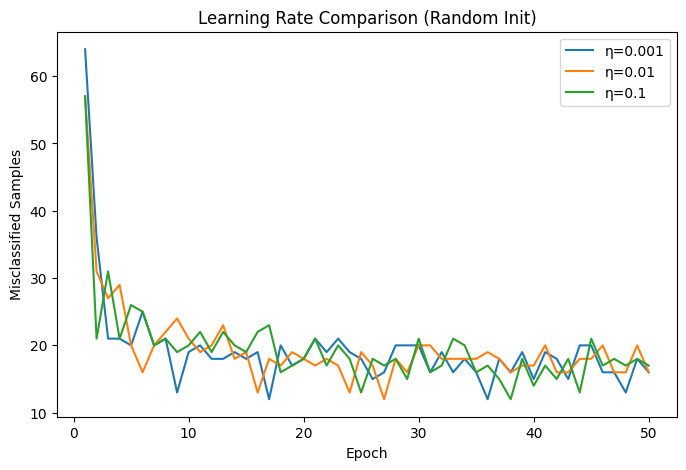

In [ ]:
class PerceptronRandomInit:
    def __init__(self, n_features, learning_rate=0.01, epochs=50, seed=42):
        np.random.seed(seed)   # same seed across runs so all 3 LRs start from the SAME random weights
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0.0
        self.lr = learning_rate
        self.epochs = epochs
        self.errors_per_epoch = []
        self.weight_history = []
        self.bias_history = []

    def step_function(self, z):
        return 1 if z >= 0 else 0

    def predict(self, x):
        z = np.dot(self.weights, x) + self.bias
        return self.step_function(z)

    def fit(self, X, y):
        for epoch in range(self.epochs):
            errors = 0
            for xi, yi in zip(X, y):
                y_pred = self.predict(xi)
                update = self.lr * (yi - y_pred)
                self.weights += update * xi
                self.bias += update
                errors += int(update != 0.0)
            self.errors_per_epoch.append(errors)
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)
        print(f"Final (lr={self.lr}): Misclassified={errors}, Weights={self.weights}, Bias={self.bias:.4f}")


# Re-run the 3 learning rates with random init
learning_rates = [0.001, 0.01, 0.1]
histories_random = {}

for lr in learning_rates:
    model_r = PerceptronRandomInit(n_features=X_train.shape[1], learning_rate=lr, epochs=50, seed=42)
    model_r.fit(X_train, y_train)
    histories_random[lr] = model_r.errors_per_epoch

# Plot comparison
plt.figure(figsize=(8,5))
for lr, errors in histories_random.items():
    plt.plot(range(1, 51), errors, label=f'η={lr}')
plt.xlabel('Epoch')
plt.ylabel('Misclassified Samples')
plt.title('Learning Rate Comparison (Random Init)')
plt.legend()
plt.show()

Random weight initialisation

Task 8

In [ ]:
from sklearn.linear_model import Perceptron

# Built-in perceptron
sk_model1 = Perceptron(eta0=0.01, max_iter=50, random_state=42)
sk_model1.fit(X_train, y_train)

y_pred_sklearn = sk_model1.predict(X_test)

print("Sklearn Weights:", sk_model1.coef_)
print("Sklearn Bias:", sk_model1.intercept_)
print("Sklearn Test Accuracy:", accuracy_score(y_test, y_pred_sklearn))

Sklearn Weights: [[-0.10135849 -0.13197251 -0.12845854 -0.00141692]]
Sklearn Bias: [-0.04]
Sklearn Test Accuracy: 0.9672727272727273


In [ ]:
from sklearn.linear_model import Perceptron

# Built-in perceptron
sk_model2 = Perceptron(eta0=0.001, max_iter=50, random_state=42)
sk_model2.fit(X_train, y_train)

y_pred_sklearn = sk_model1.predict(X_test)

print("Sklearn Weights:", sk_model2.coef_)
print("Sklearn Bias:", sk_model2.intercept_)
print("Sklearn Test Accuracy:", accuracy_score(y_test, y_pred_sklearn))

Sklearn Weights: [[-0.01013585 -0.01319725 -0.01284585 -0.00014169]]
Sklearn Bias: [-0.004]
Sklearn Test Accuracy: 0.9672727272727273


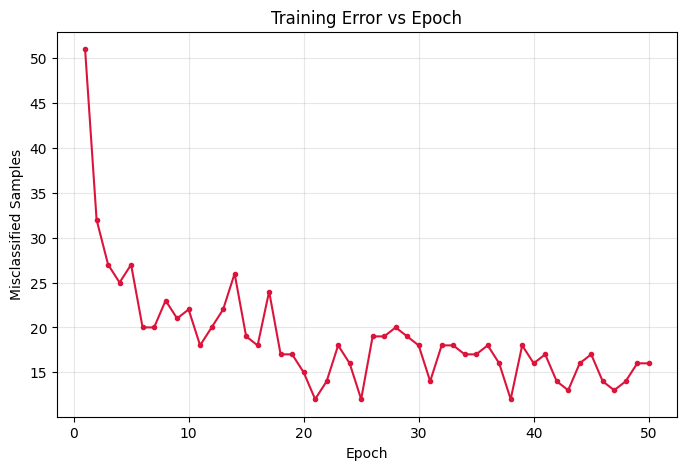

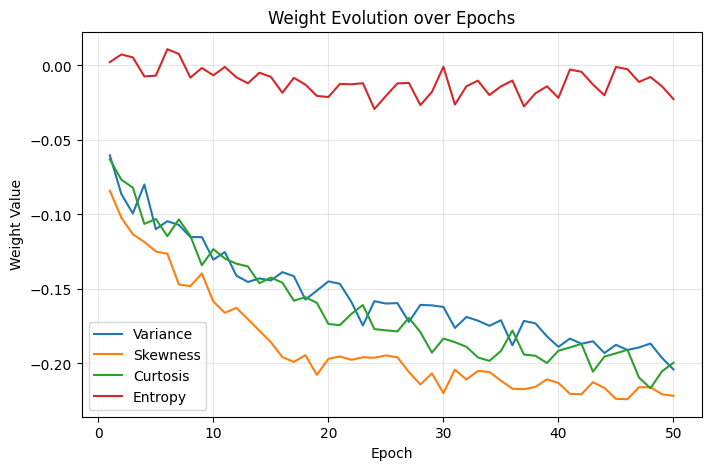

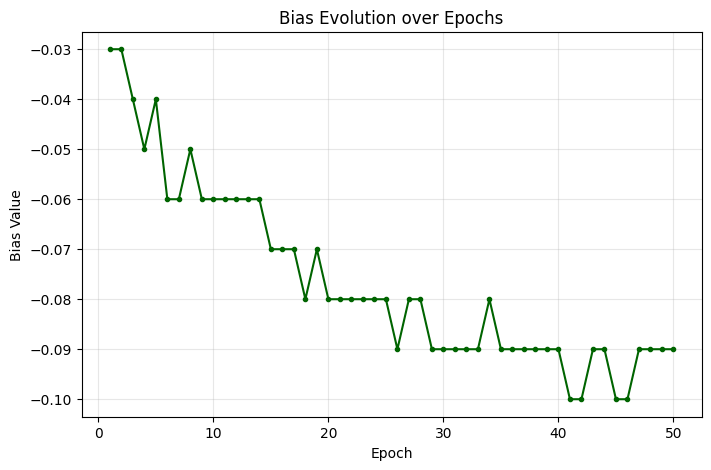

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Training Error vs Epoch ---
plt.figure(figsize=(8,5))
plt.plot(range(1, len(model1.errors_per_epoch)+1), model1.errors_per_epoch, marker='o', markersize=3, color='crimson')
plt.xlabel('Epoch')
plt.ylabel('Misclassified Samples')
plt.title('Training Error vs Epoch')
plt.grid(alpha=0.3)
plt.savefig('training_error.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Weight Evolution over Epochs ---
weight_history = np.array(model1.weight_history)  # shape: (epochs, n_features)
feature_names = ['Variance', 'Skewness', 'Curtosis', 'Entropy']

plt.figure(figsize=(8,5))
for i in range(weight_history.shape[1]):
    plt.plot(range(1, len(weight_history)+1), weight_history[:, i], label=feature_names[i])
plt.xlabel('Epoch')
plt.ylabel('Weight Value')
plt.title('Weight Evolution over Epochs')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('weight_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Bias Evolution over Epochs ---
plt.figure(figsize=(8,5))
plt.plot(range(1, len(model1.bias_history)+1), model1.bias_history, color='darkgreen', marker='o', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('Bias Value')
plt.title('Bias Evolution over Epochs')
plt.grid(alpha=0.3)
plt.savefig('bias_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

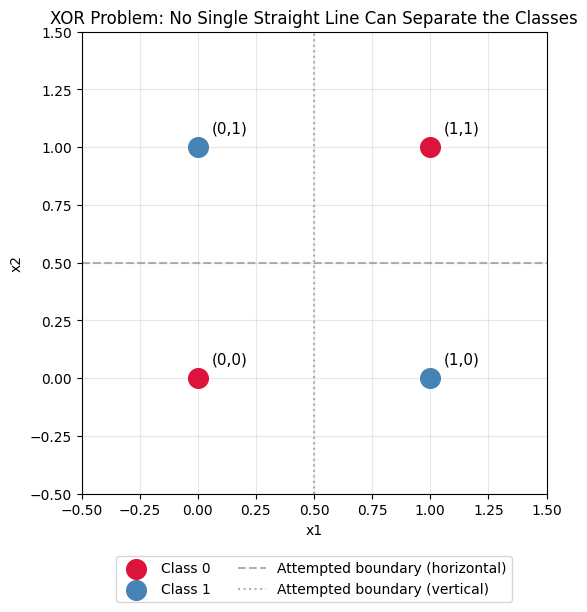

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# XOR truth table
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([0,1,1,0])

plt.figure(figsize=(6,6))

# Plot class 0 and class 1 separately for a clean legend
class0 = X_xor[y_xor==0]
class1 = X_xor[y_xor==1]

plt.scatter(class0[:,0], class0[:,1], color='crimson', s=200, label='Class 0', zorder=3)
plt.scatter(class1[:,0], class1[:,1], color='steelblue', s=200, label='Class 1', zorder=3)

# Label each point with its coordinates
for x1, x2 in X_xor:
    plt.annotate(f'({int(x1)},{int(x2)})', (x1, x2), textcoords="offset points", xytext=(10,10), fontsize=11)

# Draw a few attempted straight lines to show none can separate the classes
x_line = np.linspace(-0.5, 1.5, 100)
plt.plot(x_line, [0.5]*len(x_line), '--', color='gray', alpha=0.6, label='Attempted boundary (horizontal)')
plt.plot([0.5]*len(x_line), x_line, ':', color='gray', alpha=0.6, label='Attempted boundary (vertical)')

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('XOR Problem: No Single Straight Line Can Separate the Classes')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2)
plt.grid(alpha=0.3)
plt.savefig('xor_plot.png', dpi=150, bbox_inches='tight')
plt.show()


===== Training Perceptron for AND Gate =====
Update 1: x=[0 0], y=0, y_pred=1 -> Weights=[0. 0.], Bias=-0.100
Update 2: x=[1 1], y=1, y_pred=0 -> Weights=[0.1 0.1], Bias=0.000
Update 3: x=[0 0], y=0, y_pred=1 -> Weights=[0.1 0.1], Bias=-0.100
Update 4: x=[0 1], y=0, y_pred=1 -> Weights=[0.1 0. ], Bias=-0.200
Update 5: x=[1 1], y=1, y_pred=0 -> Weights=[0.2 0.1], Bias=-0.100
Update 6: x=[0 1], y=0, y_pred=1 -> Weights=[0.2 0. ], Bias=-0.200
Update 7: x=[1 0], y=0, y_pred=1 -> Weights=[0.1 0. ], Bias=-0.300
Update 8: x=[1 1], y=1, y_pred=0 -> Weights=[0.2 0.1], Bias=-0.200

Converged after 4 epochs (0 errors).



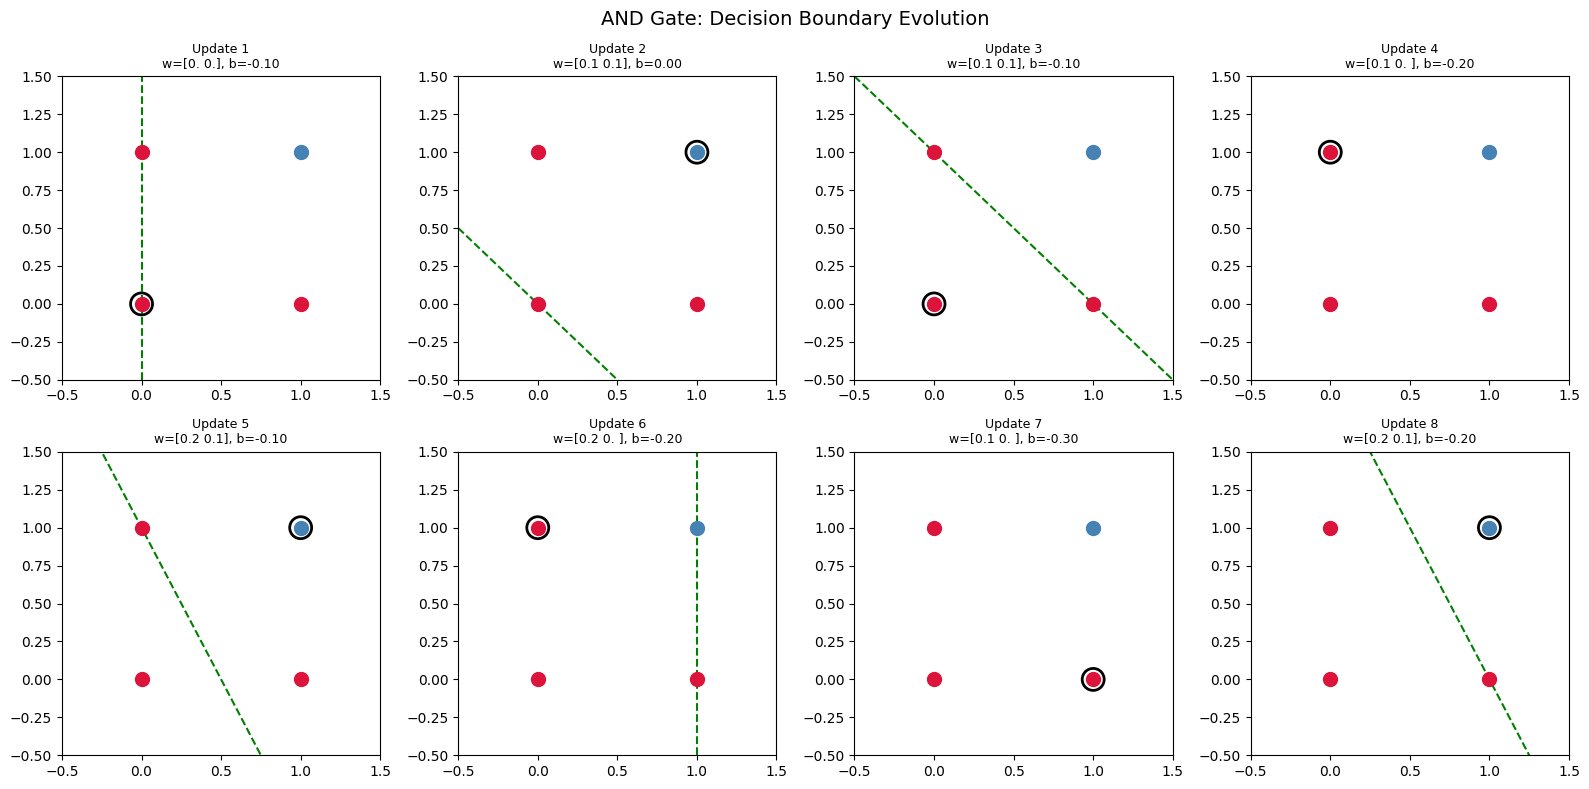


===== Training Perceptron for OR Gate =====
Update 1: x=[0 0], y=0, y_pred=1 -> Weights=[0. 0.], Bias=-0.100
Update 2: x=[0 1], y=1, y_pred=0 -> Weights=[0.  0.1], Bias=0.000
Update 3: x=[0 0], y=0, y_pred=1 -> Weights=[0.  0.1], Bias=-0.100
Update 4: x=[1 0], y=1, y_pred=0 -> Weights=[0.1 0.1], Bias=0.000
Update 5: x=[0 0], y=0, y_pred=1 -> Weights=[0.1 0.1], Bias=-0.100

Converged after 4 epochs (0 errors).



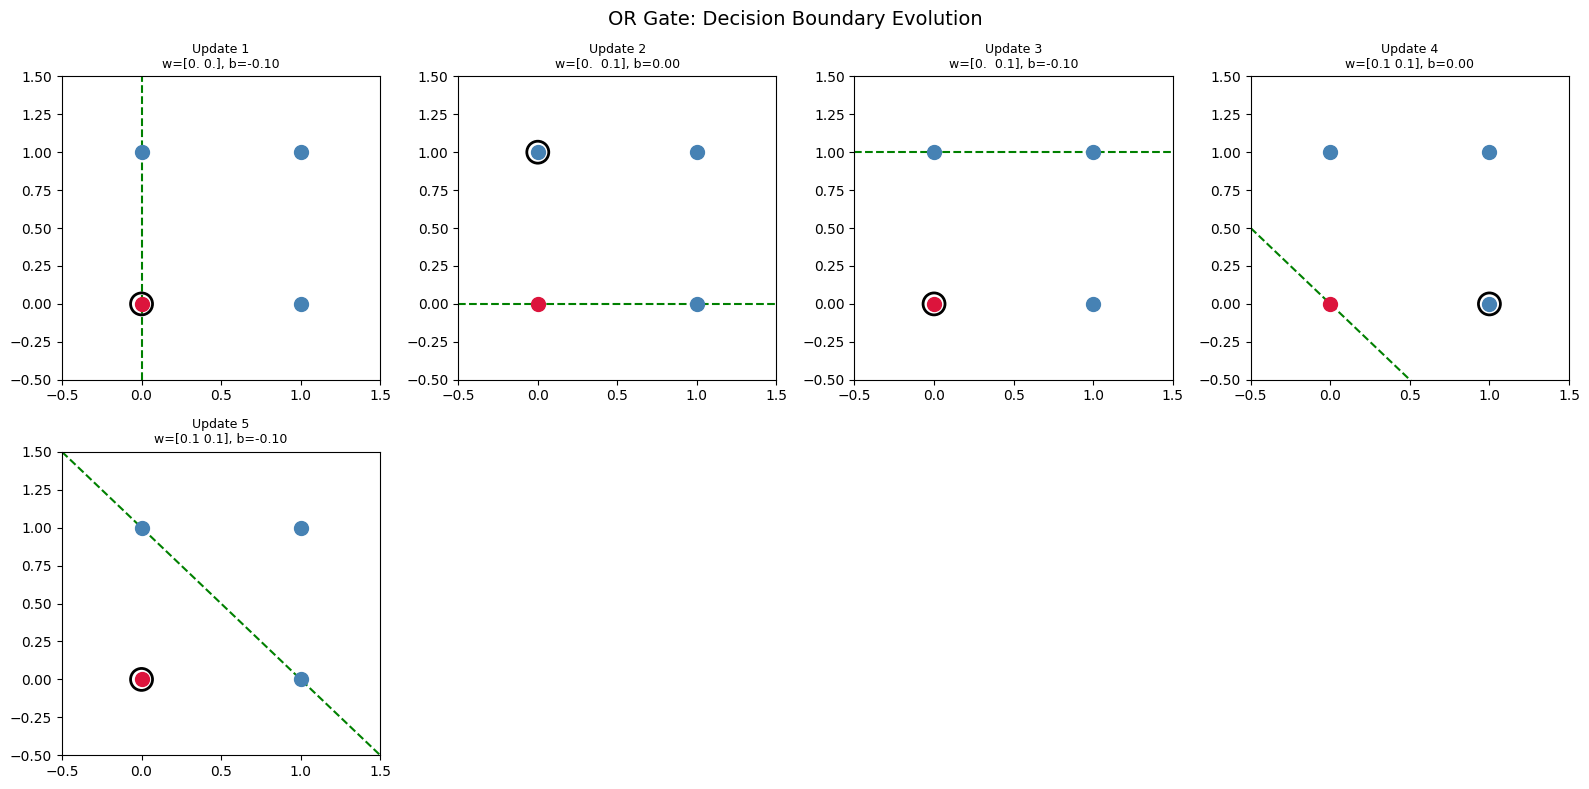


===== Training Perceptron for NOT Gate =====
Update 1: x=[1], y=0, y_pred=1 -> Weights=[-0.1], Bias=-0.100
Update 2: x=[0], y=1, y_pred=0 -> Weights=[-0.1], Bias=0.000

Converged after 3 epochs (0 errors).



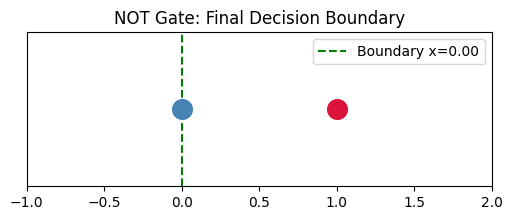


===== Training Perceptron for XOR Gate =====
Update 1: x=[0 0], y=0, y_pred=1 -> Weights=[0. 0.], Bias=-0.100
Update 2: x=[0 1], y=1, y_pred=0 -> Weights=[0.  0.1], Bias=0.000
Update 3: x=[1 1], y=0, y_pred=1 -> Weights=[-0.1  0. ], Bias=-0.100
Update 4: x=[0 1], y=1, y_pred=0 -> Weights=[-0.1  0.1], Bias=0.000
Update 5: x=[1 0], y=1, y_pred=0 -> Weights=[0.  0.1], Bias=0.100
Update 6: x=[1 1], y=0, y_pred=1 -> Weights=[-0.1  0. ], Bias=0.000
Update 7: x=[0 0], y=0, y_pred=1 -> Weights=[-0.1  0. ], Bias=-0.100
Update 8: x=[0 1], y=1, y_pred=0 -> Weights=[-0.1  0.1], Bias=0.000
Update 9: x=[1 0], y=1, y_pred=0 -> Weights=[0.  0.1], Bias=0.100
Update 10: x=[1 1], y=0, y_pred=1 -> Weights=[-0.1  0. ], Bias=0.000
Update 11: x=[0 0], y=0, y_pred=1 -> Weights=[-0.1  0. ], Bias=-0.100
Update 12: x=[0 1], y=1, y_pred=0 -> Weights=[-0.1  0.1], Bias=0.000
Update 13: x=[1 0], y=1, y_pred=0 -> Weights=[0.  0.1], Bias=0.100
Update 14: x=[1 1], y=0, y_pred=1 -> Weights=[-0.1  0. ], Bias=0.000
Updat

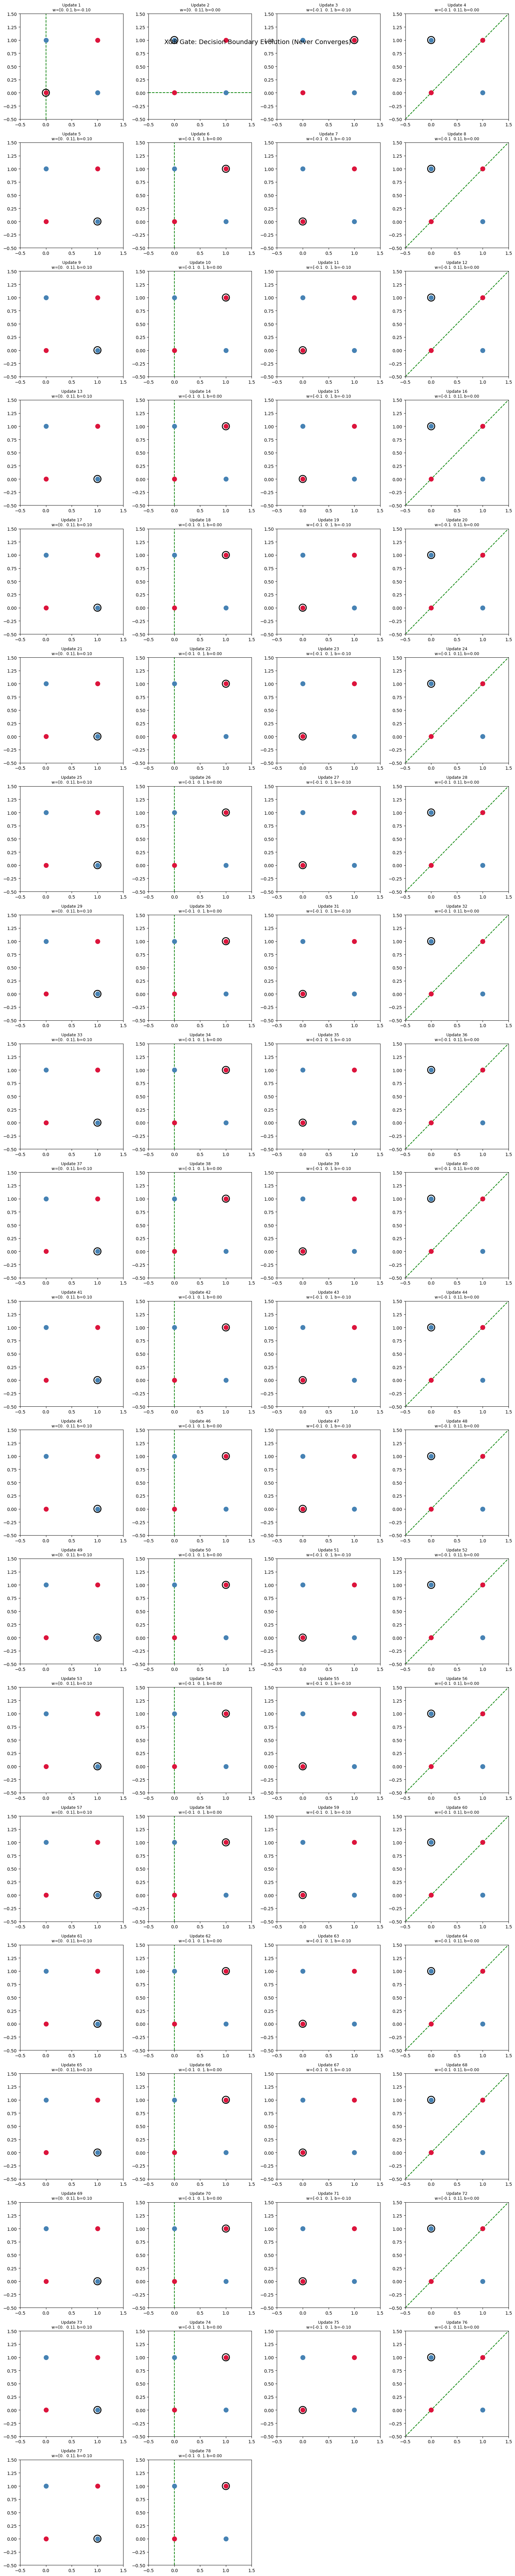

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class GatePerceptron:
    def __init__(self, n_features, learning_rate=0.1, max_epochs=20):
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.lr = learning_rate
        self.max_epochs = max_epochs
        self.update_log = []   # stores (weights_copy, bias, x, y, y_pred) after EVERY update

    def step_function(self, z):
        return 1 if z >= 0 else 0

    def predict(self, x):
        z = np.dot(self.weights, x) + self.bias
        return self.step_function(z)

    def fit(self, X, y):
        converged = False
        for epoch in range(self.max_epochs):
            total_errors = 0
            for xi, yi in zip(X, y):
                y_pred = self.predict(xi)
                error = yi - y_pred
                if error != 0:
                    self.weights += self.lr * error * xi
                    self.bias += self.lr * error
                    total_errors += 1
                    self.update_log.append((self.weights.copy(), self.bias, xi, yi, y_pred))
                    print(f"Update {len(self.update_log)}: x={xi}, y={yi}, y_pred={y_pred} "
                          f"-> Weights={self.weights}, Bias={self.bias:.3f}")
            if total_errors == 0:
                print(f"\nConverged after {epoch+1} epochs (0 errors).\n")
                converged = True
                break
        if not converged:
            print(f"\nDid NOT converge within {self.max_epochs} epochs.\n")


def plot_boundary_evolution(model, X, y, title, filename):
    n_updates = len(model.update_log)
    cols = 4
    rows = int(np.ceil(n_updates / cols)) if n_updates > 0 else 1
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = np.array(axes).reshape(-1)

    for i, (w, b, xi, yi, y_pred) in enumerate(model.update_log):
        ax = axes[i]
        for xp, yp in zip(X, y):
            ax.scatter(xp[0], xp[1], c='crimson' if yp==0 else 'steelblue', s=100, zorder=3)
        ax.scatter(xi[0], xi[1], facecolors='none', edgecolors='black', s=250, linewidths=2, zorder=4)

        x_vals = np.linspace(-0.5, 1.5, 100)
        if w[1] != 0:
            y_vals = -(w[0]*x_vals + b) / w[1]
            ax.plot(x_vals, y_vals, 'g--')
        else:
            ax.axvline(x=-b/w[0] if w[0] != 0 else 0, color='g', linestyle='--')

        ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
        ax.set_title(f"Update {i+1}\nw={np.round(w,2)}, b={b:.2f}", fontsize=9)

    for j in range(n_updates, len(axes)):
        axes[j].axis('off')

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()


# ============ Task 1: AND, OR gates (2D) ============
gates_2d = {
    "AND": (np.array([[0,0],[0,1],[1,0],[1,1]]), np.array([0,0,0,1])),
    "OR":  (np.array([[0,0],[0,1],[1,0],[1,1]]), np.array([0,1,1,1])),
}

for name, (X, y) in gates_2d.items():
    print(f"\n===== Training Perceptron for {name} Gate =====")
    model = GatePerceptron(n_features=2, learning_rate=0.1, max_epochs=20)
    model.fit(X, y)
    plot_boundary_evolution(model, X, y, f"{name} Gate: Decision Boundary Evolution", f"{name.lower()}_boundary.png")


# ============ Task 1: NOT gate (1D) ============
print("\n===== Training Perceptron for NOT Gate =====")
X_not = np.array([[0],[1]])
y_not = np.array([1,0])
model_not = GatePerceptron(n_features=1, learning_rate=0.1, max_epochs=20)
model_not.fit(X_not, y_not)

# Simple 1D plot: decision boundary is a single point on the number line
fig, ax = plt.subplots(figsize=(6,2))
for xp, yp in zip(X_not, y_not):
    ax.scatter(xp[0], 0, c='crimson' if yp==0 else 'steelblue', s=200, zorder=3)
final_w, final_b = model_not.weights[0], model_not.bias
if final_w != 0:
    boundary_x = -final_b/final_w
    ax.axvline(x=boundary_x, color='g', linestyle='--', label=f'Boundary x={boundary_x:.2f}')
ax.set_yticks([])
ax.set_xlim(-1, 2)
ax.legend()
ax.set_title("NOT Gate: Final Decision Boundary")
plt.savefig("not_boundary.png", dpi=150, bbox_inches='tight')
plt.show()


# ============ Task 2: XOR gate ============
print("\n===== Training Perceptron for XOR Gate =====")
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([0,1,1,0])
model_xor = GatePerceptron(n_features=2, learning_rate=0.1, max_epochs=20)
model_xor.fit(X_xor, y_xor)
plot_boundary_evolution(model_xor, X_xor, y_xor, "XOR Gate: Decision Boundary Evolution (Never Converges)", "xor_boundary.png")